# 🌿 AgriScan — Transfer Learning Training Pipeline

**CS 719 · Data Science Project · University of Regina · Winter 2026**  
**Student:** Viral Prajapati (200499893) · **Instructor:** Howard J. Hamilton

---

## Overview

This notebook trains and compares **5 CNN architectures** for plant disease detection:

| # | Model | Input | Epochs | Strategy |
|---|-------|-------|--------|-----------|
| 1 | Baseline CNN | 128×128 | 10 | Trained from scratch (reference) |
| 2 | MobileNetV2 | 224×224 | 10 | Transfer learning — partial unfreeze |
| 3 | EfficientNetB0 ✅ | 224×224 | 10 | Transfer learning — partial unfreeze |
| 4 | ResNet50 | 224×224 | 10 | Transfer learning — partial unfreeze |
| 5 | DenseNet121 | 224×224 | 10 | Transfer learning — partial unfreeze |

> ⚠️ **VGG16 has been removed** — it is computationally expensive (~20 min) and consistently underperforms compared to EfficientNetB0 and DenseNet121 at similar or lower parameter counts.

**Every model is capped at exactly 10 epochs.** `EarlyStopping(patience=3)` will stop sooner if validation loss stops improving.

---

## ⏱ Estimated Training Time on Kaggle T4/P100 GPU

| Model | Estimated Time |
|-------|----------------|
| Baseline CNN | ~10 min |
| MobileNetV2 | ~12 min |
| EfficientNetB0 | ~15 min |
| ResNet50 | ~18 min |
| DenseNet121 | ~17 min |
| **Total (all 5)** | **~1.2 hrs** |

---

## ⚠️ Before Running

1. Make sure the **PlantVillage dataset** is attached (see `dataSources` in notebook metadata)  
   → Dataset: `abdallahalidev/plantvillage-dataset`
2. Enable **GPU accelerator**: Session Options → Accelerator

## ✅ Step 0 — Check GPU & Environment

In [5]:
import tensorflow as tf
print("TensorFlow version :", tf.__version__)
print("GPU devices        :", tf.config.list_physical_devices('GPU'))
print()

if not tf.config.list_physical_devices('GPU'):
    print("⚠️  WARNING: No GPU detected. Training will be very slow on CPU.")
    print("   → In Kaggle: Settings → Accelerator → GPU T4 x2")
else:
    print("✅ GPU available — training will be fast.")

TensorFlow version : 2.19.0
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

✅ GPU available — training will be fast.


## 📦 Step 1 — Imports

In [6]:
import os, json, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import (
    MobileNetV2, EfficientNetB0, ResNet50, DenseNet121,
)
from tensorflow.keras.applications.mobilenet_v2  import preprocess_input as mob_pre
from tensorflow.keras.applications.efficientnet  import preprocess_input as eff_pre
from tensorflow.keras.applications.resnet50      import preprocess_input as res_pre
from tensorflow.keras.applications.densenet      import preprocess_input as dns_pre
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

print("✅ All imports successful")

✅ All imports successful


## ⚙️ Step 2 — Configuration

All hyperparameters in one place. **Max 10 epochs for every model.**

In [7]:
CFG = {
    # —— Image sizes ————————————————————————————————————
    "img_size":      224,      # Input size for all pre-trained models
    "img_size_base": 128,      # Baseline CNN (128×128)

    # —— Training ————————————————————————————————————————
    "batch_size":    32,
    "num_classes":   38,
    "random_state":  42,
    "epochs":        10,       # ← MAX EPOCHS FOR EVERY MODEL (no exceptions)
    "learning_rate": 1e-3,     # Initial LR for all models

    # —— Dataset splits ———————————————————————————————————
    "train_ratio":   0.70,
    "val_ratio":     0.15,
    "test_ratio":    0.15,

    # —— Data augmentation ————————————————————————————————
    "aug_target":    1500,     # Target images per underrepresented class

    # —— Kaggle paths —————————————————————————————————————
    "dataset_path":  None,     # Filled after dataset lookup below
    "output_dir":    "/kaggle/working/models",
    "results_dir":   "/kaggle/working/results",
}

os.makedirs(CFG["output_dir"],  exist_ok=True)
os.makedirs(CFG["results_dir"], exist_ok=True)

print("Configuration:")
for k, v in CFG.items():
    print(f"  {k:<18} = {v}")

Configuration:
  img_size           = 224
  img_size_base      = 128
  batch_size         = 32
  num_classes        = 38
  random_state       = 42
  epochs             = 10
  learning_rate      = 0.001
  train_ratio        = 0.7
  val_ratio          = 0.15
  test_ratio         = 0.15
  aug_target         = 1500
  dataset_path       = None
  output_dir         = /kaggle/working/models
  results_dir        = /kaggle/working/results


## 🌱 Step 3 — Locate PlantVillage Dataset

On Kaggle the dataset is **pre-attached** — no download needed.  
The cell below discovers the correct path automatically.

In [8]:
# ── Locate the 'color' sub-folder inside the attached dataset ──────────────────
INPUT_BASE = "/kaggle/input"
DATASET_PATH = None

# Walk /kaggle/input to find the 'color' folder (PlantVillage colour images)
for root, dirs, files in os.walk(INPUT_BASE):
    if os.path.basename(root).lower() == "color" and len(dirs) > 10:
        DATASET_PATH = root
        break

if DATASET_PATH is None:
    # Fallback: try common path patterns
    candidates = [
        "/kaggle/input/plantvillage-dataset/color",
        "/kaggle/input/plantvillage-dataset/PlantVillage",
        "/kaggle/input/plant-village-dataset/color",
    ]
    for c in candidates:
        if os.path.isdir(c):
            DATASET_PATH = c
            break

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Could not find PlantVillage 'color' folder.\n"
        "Make sure the dataset 'abdallahalidev/plantvillage-dataset' "
        "is attached in the notebook's data settings."
    )

CFG["dataset_path"] = DATASET_PATH
print(f"✅ Dataset found : {DATASET_PATH}")

# ── Enumerate class labels ─────────────────────────────────────────────────────
labels = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f"\nTotal disease classes: {len(labels)}")
for i, l in enumerate(labels):
    print(f"  {i+1:>2}. {l}")

✅ Dataset found : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color

Total disease classes: 38
   1. Apple___Apple_scab
   2. Apple___Black_rot
   3. Apple___Cedar_apple_rust
   4. Apple___healthy
   5. Blueberry___healthy
   6. Cherry_(including_sour)___Powdery_mildew
   7. Cherry_(including_sour)___healthy
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   9. Corn_(maize)___Common_rust_
  10. Corn_(maize)___Northern_Leaf_Blight
  11. Corn_(maize)___healthy
  12. Grape___Black_rot
  13. Grape___Esca_(Black_Measles)
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  15. Grape___healthy
  16. Orange___Haunglongbing_(Citrus_greening)
  17. Peach___Bacterial_spot
  18. Peach___healthy
  19. Pepper,_bell___Bacterial_spot
  20. Pepper,_bell___healthy
  21. Potato___Early_blight
  22. Potato___Late_blight
  23. Potato___healthy
  24. Raspberry___healthy
  25. Soybean___healthy
  26. Squash___Powdery_mildew
  27. Strawberry___Leaf_scorch
  28. Stra

## 📊 Step 4 — Load Image Paths & Exploratory Data Analysis

Total images    : 54,305
Total classes   : 38
Min images/class: 152
Max images/class: 5507
Avg images/class: 1429.1
Std images/class: 1254.9


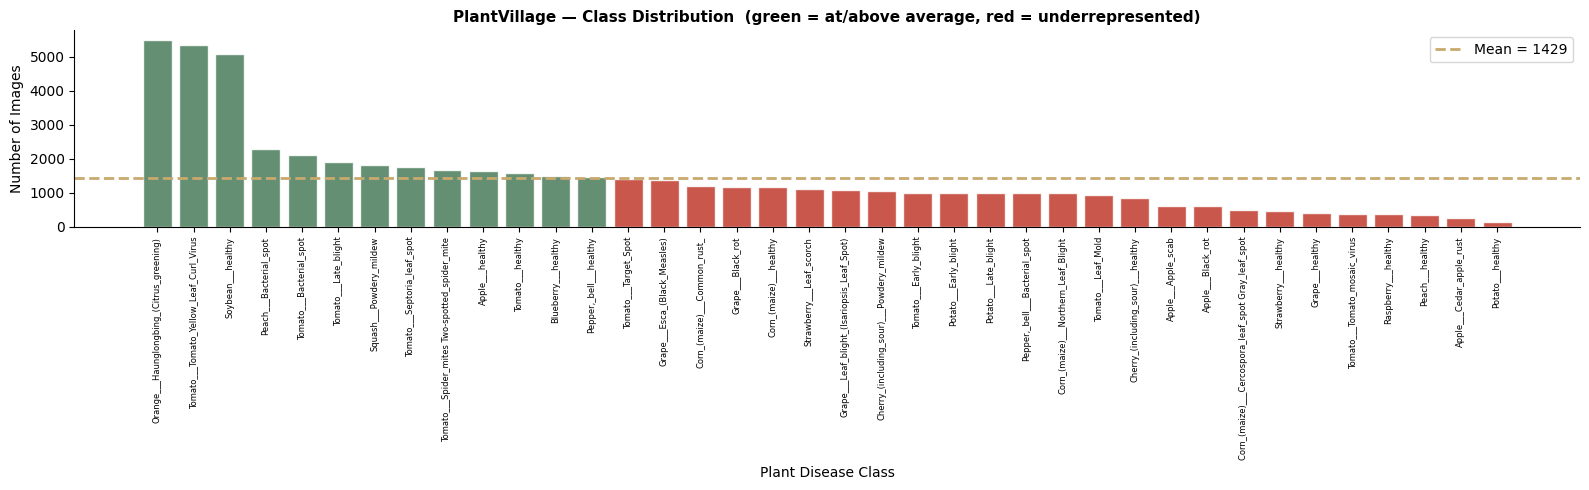

In [9]:
all_paths, all_labels = [], []
label_counts = {}

for label in labels:
    label_dir = os.path.join(DATASET_PATH, label)
    files = [f for f in os.listdir(label_dir)
             if os.path.isfile(os.path.join(label_dir, f))]
    label_counts[label] = len(files)
    for fname in files:
        all_paths.append(os.path.join(label_dir, fname))
        all_labels.append(label)

print(f"Total images    : {len(all_paths):,}")
print(f"Total classes   : {len(labels)}")
print(f"Min images/class: {min(label_counts.values())}")
print(f"Max images/class: {max(label_counts.values())}")
print(f"Avg images/class: {np.mean(list(label_counts.values())):.1f}")
print(f"Std images/class: {np.std(list(label_counts.values())):.1f}")

# ── EDA 1: Class distribution bar chart ────────────────────────────────────
df_counts = pd.DataFrame(label_counts.items(), columns=["Label", "Count"])
df_counts = df_counts.sort_values("Count", ascending=False)
avg = np.mean(list(label_counts.values()))

fig, ax = plt.subplots(figsize=(16, 5))
bar_colors = ["#4a7c59" if c >= avg else "#c0392b" for c in df_counts["Count"]]
ax.bar(df_counts["Label"], df_counts["Count"], color=bar_colors, alpha=0.85, edgecolor="white")
ax.axhline(avg, color="#c8a96e", linestyle="--", linewidth=2, label=f"Mean = {avg:.0f}")
ax.set_xlabel("Plant Disease Class"); ax.set_ylabel("Number of Images")
ax.set_title("PlantVillage — Class Distribution  (green = at/above average, red = underrepresented)",
             fontsize=11, fontweight="bold")
ax.set_xticks(range(len(df_counts)))
ax.set_xticklabels(df_counts["Label"], rotation=90, fontsize=6)
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG["results_dir"], "eda_class_distribution.png"), dpi=150)
plt.show()

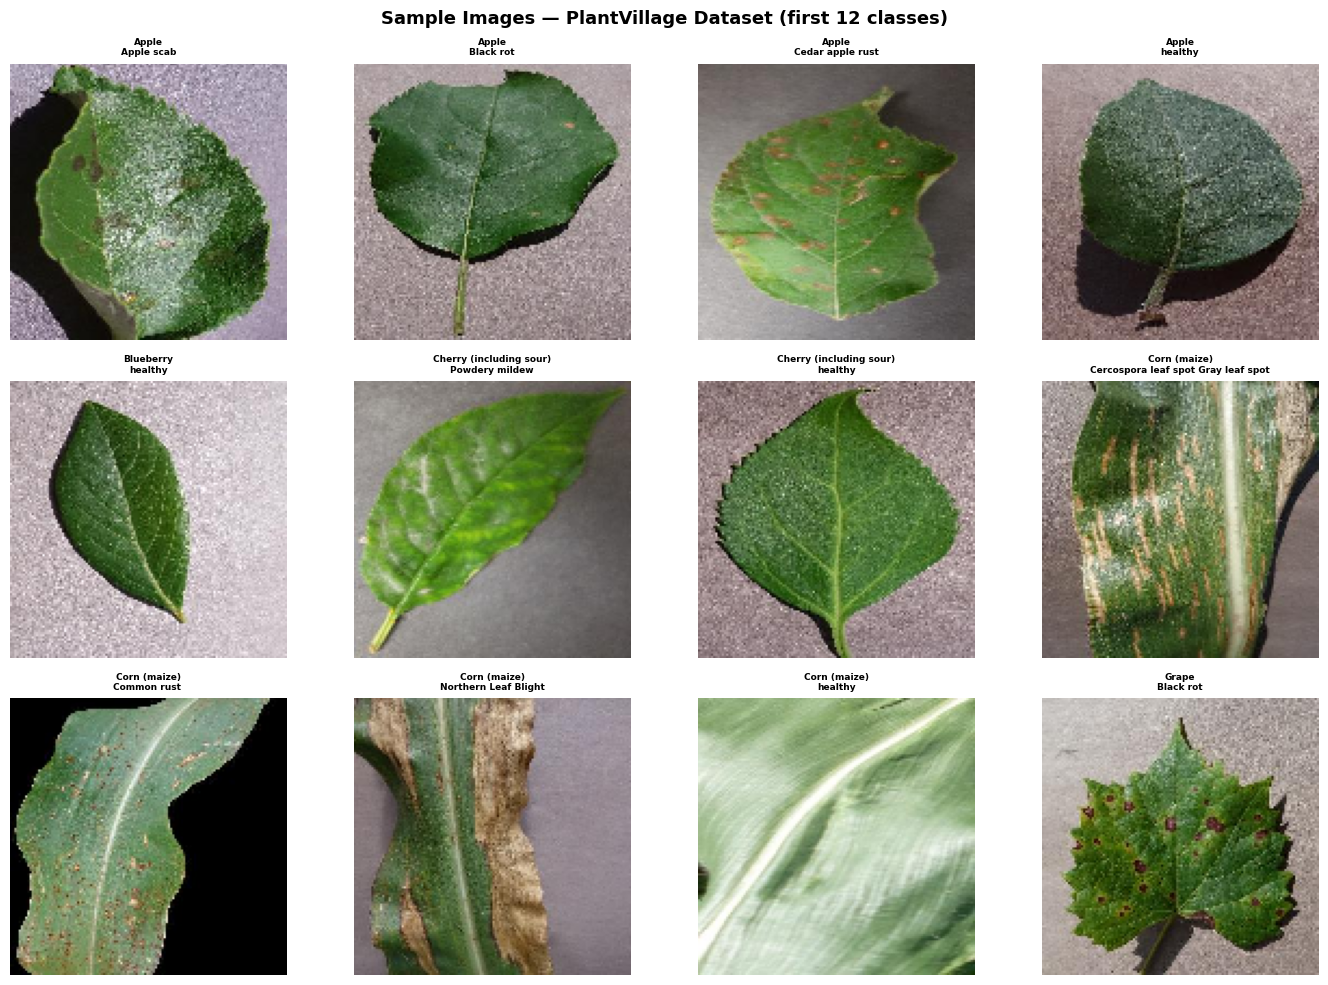

In [10]:
# ── EDA 2: Sample images (one per class, first 12 classes) ────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Sample Images — PlantVillage Dataset (first 12 classes)", fontsize=13, fontweight="bold")
for ax, cls in zip(axes.flatten(), labels[:12]):
    cls_dir = os.path.join(DATASET_PATH, cls)
    img_file = [f for f in os.listdir(cls_dir) if not f.startswith(".")][0]
    img = load_img(os.path.join(cls_dir, img_file), target_size=(128, 128))
    ax.imshow(img)
    ax.set_title(cls.replace("___", "\n").replace("_", " "), fontsize=6.5, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(CFG["results_dir"], "eda_sample_images.png"), dpi=150)
plt.show()

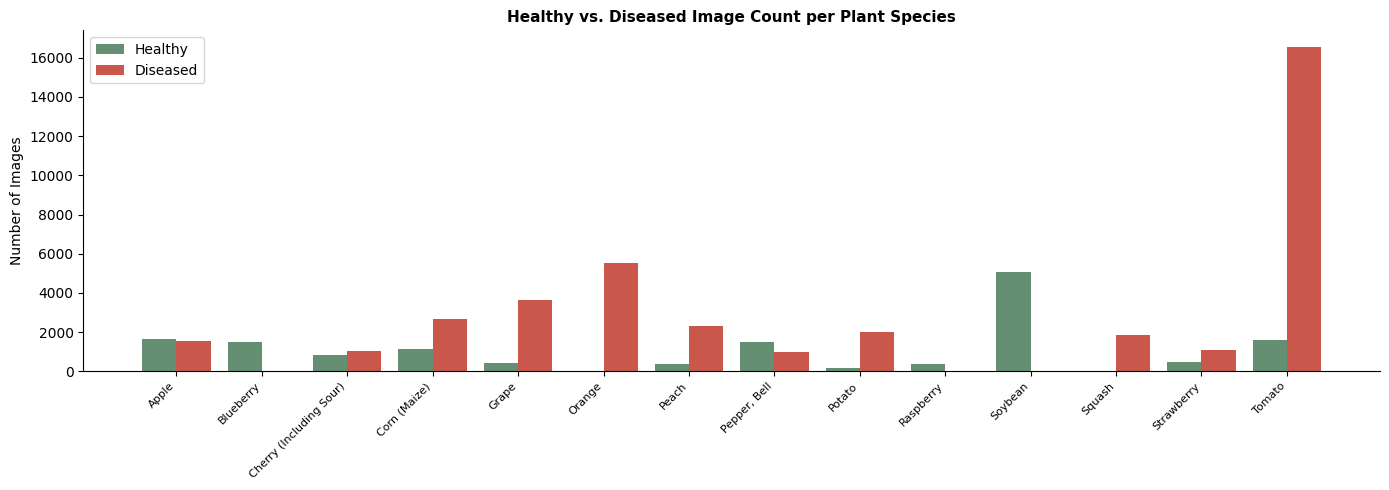

Total healthy images  : 15,084  (27.8%)
Total diseased images : 39,221  (72.2%)


In [11]:
# ── EDA 3: Healthy vs. Diseased breakdown per plant species ──────────────────
plant_healthy = {}
plant_diseased = {}

for label, cnt in label_counts.items():
    parts = label.split("___")
    plant = parts[0].replace("_", " ").title()
    condition = parts[1] if len(parts) > 1 else "Unknown"
    if condition.lower() == "healthy":
        plant_healthy[plant] = plant_healthy.get(plant, 0) + cnt
    else:
        plant_diseased[plant] = plant_diseased.get(plant, 0) + cnt

all_plants = sorted(set(list(plant_healthy.keys()) + list(plant_diseased.keys())))
h_vals = [plant_healthy.get(p, 0) for p in all_plants]
d_vals = [plant_diseased.get(p, 0) for p in all_plants]

x = np.arange(len(all_plants))
width = 0.4
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, h_vals, width, label="Healthy",  color="#4a7c59", alpha=0.85)
ax.bar(x + width/2, d_vals, width, label="Diseased", color="#c0392b", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_plants, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of Images")
ax.set_title("Healthy vs. Diseased Image Count per Plant Species", fontsize=11, fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG["results_dir"], "eda_healthy_vs_diseased.png"), dpi=150)
plt.show()

total_healthy  = sum(h_vals)
total_diseased = sum(d_vals)
print(f"Total healthy images  : {total_healthy:,}  ({100*total_healthy/len(all_paths):.1f}%)")
print(f"Total diseased images : {total_diseased:,}  ({100*total_diseased/len(all_paths):.1f}%)")

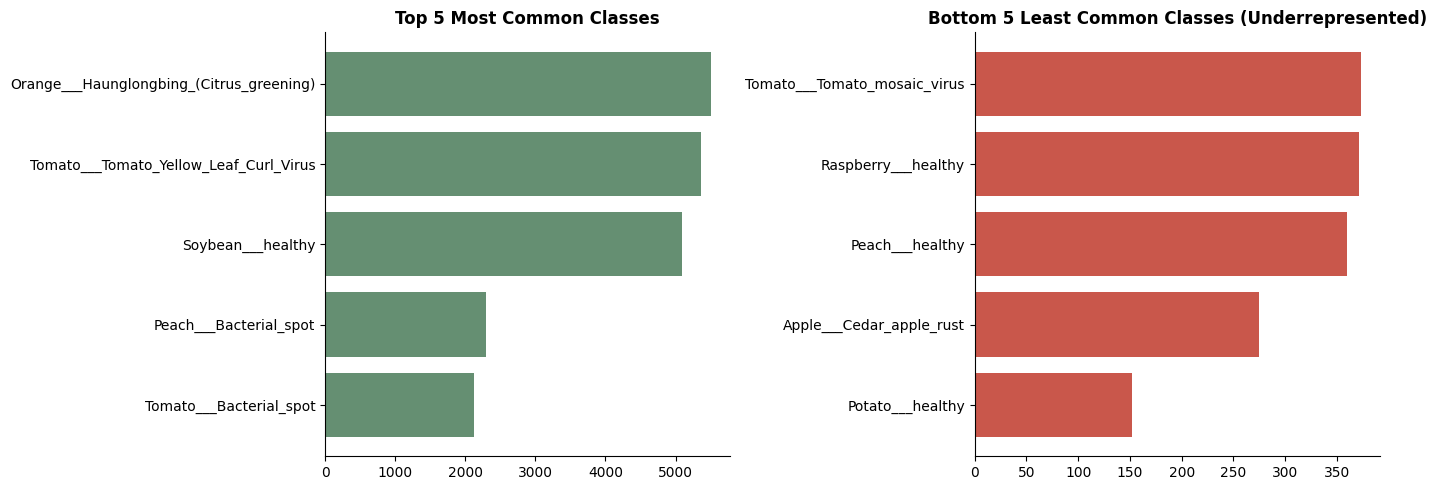

In [12]:
# ── EDA 4: Top-5 and Bottom-5 classes ────────────────────────────────────────
df_top5    = df_counts.head(5)
df_bottom5 = df_counts.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(df_top5["Label"], df_top5["Count"], color="#4a7c59", alpha=0.85)
axes[0].set_title("Top 5 Most Common Classes", fontweight="bold")
axes[0].invert_yaxis()
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(df_bottom5["Label"], df_bottom5["Count"], color="#c0392b", alpha=0.85)
axes[1].set_title("Bottom 5 Least Common Classes (Underrepresented)", fontweight="bold")
axes[1].invert_yaxis()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CFG["results_dir"], "eda_top_bottom_classes.png"), dpi=150)
plt.show()

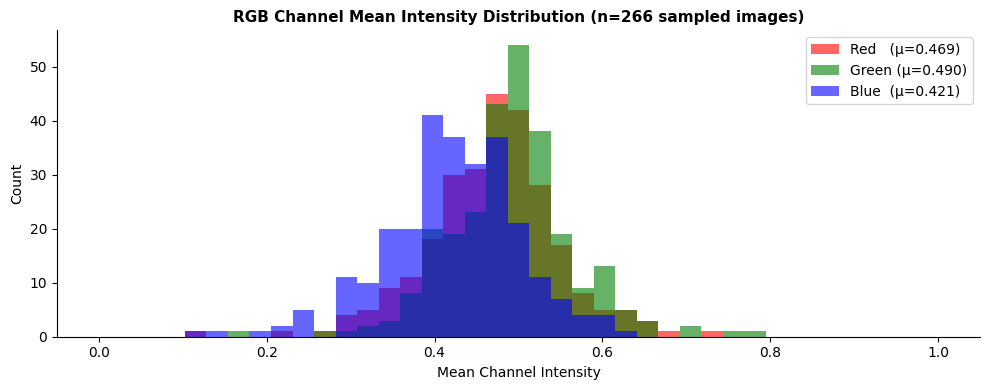

Channel means  →  R: 0.4694 | G: 0.4903 | B: 0.4213
Channel stds   →  R: 0.0783 | G: 0.0748 | B: 0.0792


In [13]:
# ── EDA 5: Mean pixel intensity distribution across a sample of images ─────
# Sample 300 images evenly across classes (lightweight — no GPU needed)
sample_paths = []
per_class = max(1, 300 // len(labels))
for label in labels:
    cls_files = [p for p, l in zip(all_paths, all_labels) if l == label][:per_class]
    sample_paths.extend(cls_files)

r_means, g_means, b_means = [], [], []
for p in sample_paths:
    try:
        img = np.array(load_img(p, target_size=(64, 64))) / 255.0
        r_means.append(img[:,:,0].mean())
        g_means.append(img[:,:,1].mean())
        b_means.append(img[:,:,2].mean())
    except Exception:
        continue

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 1, 40)
ax.hist(r_means, bins=bins, alpha=0.6, color="red",   label=f"Red   (μ={np.mean(r_means):.3f})")
ax.hist(g_means, bins=bins, alpha=0.6, color="green", label=f"Green (μ={np.mean(g_means):.3f})")
ax.hist(b_means, bins=bins, alpha=0.6, color="blue",  label=f"Blue  (μ={np.mean(b_means):.3f})")
ax.set_xlabel("Mean Channel Intensity"); ax.set_ylabel("Count")
ax.set_title(f"RGB Channel Mean Intensity Distribution (n={len(r_means)} sampled images)",
             fontsize=11, fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG["results_dir"], "eda_rgb_distribution.png"), dpi=150)
plt.show()

print(f"Channel means  →  R: {np.mean(r_means):.4f} | G: {np.mean(g_means):.4f} | B: {np.mean(b_means):.4f}")
print(f"Channel stds   →  R: {np.std(r_means):.4f} | G: {np.std(g_means):.4f} | B: {np.std(b_means):.4f}")

## ✂️ Step 5 — Train / Validation / Test Split

In [14]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - CFG["train_ratio"],
    random_state=CFG["random_state"],
    stratify=all_labels,
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=CFG["test_ratio"] / (CFG["val_ratio"] + CFG["test_ratio"]),
    random_state=CFG["random_state"],
    stratify=temp_labels,
)

print(f"Train size : {len(train_paths):,}  ({100*len(train_paths)/len(all_paths):.1f}%)")
print(f"Val size   : {len(val_paths):,}  ({100*len(val_paths)/len(all_paths):.1f}%)")
print(f"Test size  : {len(test_paths):,}  ({100*len(test_paths)/len(all_paths):.1f}%)")

Train size : 38,013  (70.0%)
Val size   : 8,146  (15.0%)
Test size  : 8,146  (15.0%)


## 🏷️ Step 6 — Label Encoding

In [15]:
all_unique = sorted(set(train_labels + val_labels + test_labels))
label_encoder = LabelEncoder()
label_encoder.fit(all_unique)
CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES  = len(CLASS_NAMES)
print(f"Number of classes : {NUM_CLASSES}")

def encode_labels(label_list):
    ints = label_encoder.transform(label_list)
    return to_categorical(ints, num_classes=NUM_CLASSES)

train_cat = encode_labels(train_labels)
val_cat   = encode_labels(val_labels)
test_cat  = encode_labels(test_labels)
print("✅ Labels encoded to one-hot categorical format")

Number of classes : 38
✅ Labels encoded to one-hot categorical format


## 🔄 Step 7 — Data Augmentation

Classes below the mean count are augmented up to **1,500 images** each.

In [16]:
train_counts = Counter(train_labels)
avg_count    = np.mean(list(train_counts.values()))
underrep     = [lbl for lbl, cnt in train_counts.items() if cnt < avg_count]

print(f"Average images per class : {avg_count:.0f}")
print(f"Underrepresented classes : {len(underrep)}")
print(f"Augmentation target      : {CFG['aug_target']} images per class")

datagen = ImageDataGenerator(
    rotation_range=40,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
)

aug_dir = "/kaggle/working/augmented_images"
if os.path.exists(aug_dir):
    shutil.rmtree(aug_dir)
os.makedirs(aug_dir)

augmented_paths, augmented_labels = [], []
target = CFG["aug_target"]

print(f"\nAugmenting underrepresented classes to {target} images...")
print("-" * 65)

for label in underrep:
    current = train_counts[label]
    need    = target - current
    if need <= 0:
        continue

    label_aug_dir = os.path.join(aug_dir, label)
    os.makedirs(label_aug_dir, exist_ok=True)

    src_imgs = [p for p, l in zip(train_paths, train_labels) if l == label]
    imgs = []
    for ip in src_imgs:
        try:
            imgs.append(img_to_array(load_img(ip, target_size=(CFG["img_size"], CFG["img_size"]))))
        except Exception:
            continue

    if not imgs:
        continue

    generated = 0
    for batch in datagen.flow(np.array(imgs), batch_size=1,
                               save_to_dir=label_aug_dir,
                               save_prefix="aug", save_format="jpeg"):
        generated += 1
        if generated >= need:
            break

    for fname in os.listdir(label_aug_dir):
        if fname.startswith("aug"):
            augmented_paths.append(os.path.join(label_aug_dir, fname))
            augmented_labels.append(label)

    print(f"  {label[:55]:<55} {current:>4} → {current+generated} (+{generated})")

print("-" * 65)
print(f"\n✅ Total augmented images generated: {len(augmented_paths):,}")

Average images per class : 1000
Underrepresented classes : 25
Augmentation target      : 1500 images per class

Augmenting underrepresented classes to 1500 images...
-----------------------------------------------------------------
  Apple___Cedar_apple_rust                                 193 → 1500 (+1307)
  Raspberry___healthy                                      260 → 1500 (+1240)
  Potato___Early_blight                                    700 → 1500 (+800)
  Corn_(maize)___healthy                                   813 → 1500 (+687)
  Corn_(maize)___Northern_Leaf_Blight                      690 → 1500 (+810)
  Grape___Black_rot                                        826 → 1500 (+674)
  Cherry_(including_sour)___healthy                        598 → 1500 (+902)
  Corn_(maize)___Common_rust_                              834 → 1500 (+666)
  Grape___Esca_(Black_Measles)                             968 → 1500 (+532)
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)               753 → 1500 (+7

Original training size : 38,013
Balanced training size : 61,147  (+23,134 augmented)

Post-augmentation stats:
  Min images/class : 1035
  Max images/class : 3855
  Mean images/class: 1609


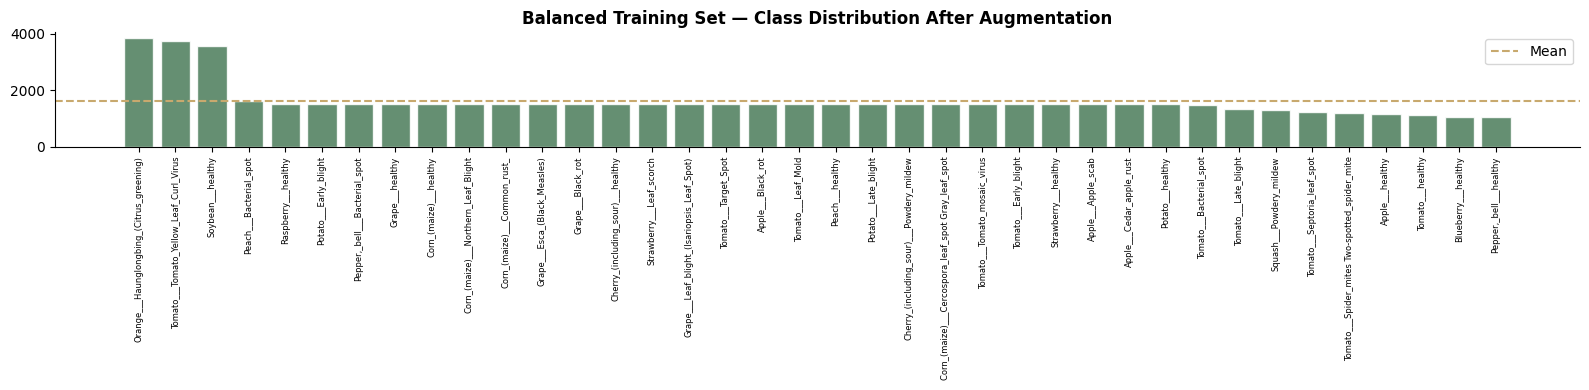

In [17]:
# Combine original + augmented training data
balanced_train_paths  = train_paths + augmented_paths
balanced_train_labels = train_labels + augmented_labels
balanced_train_cat    = encode_labels(balanced_train_labels)

print(f"Original training size : {len(train_paths):,}")
print(f"Balanced training size : {len(balanced_train_paths):,}  (+{len(augmented_paths):,} augmented)")

# Verify new distribution
balanced_counts = Counter(balanced_train_labels)
print(f"\nPost-augmentation stats:")
print(f"  Min images/class : {min(balanced_counts.values())}")
print(f"  Max images/class : {max(balanced_counts.values())}")
print(f"  Mean images/class: {np.mean(list(balanced_counts.values())):.0f}")

# Plot balanced distribution
df_bal = pd.DataFrame(balanced_counts.items(), columns=["Label", "Count"]).sort_values("Count", ascending=False)
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(df_bal["Label"], df_bal["Count"], color="#4a7c59", alpha=0.85, edgecolor="white")
ax.axhline(np.mean(df_bal["Count"]), color="#c8a96e", linestyle="--", linewidth=1.5, label="Mean")
ax.set_title("Balanced Training Set — Class Distribution After Augmentation", fontweight="bold")
ax.set_xticks(range(len(df_bal)))
ax.set_xticklabels(df_bal["Label"], rotation=90, fontsize=6)
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG["results_dir"], "eda_balanced_distribution.png"), dpi=150)
plt.show()

## ⚡ Step 8 — tf.data Pipeline & Shared Utilities

In [18]:
def make_dataset(paths, labels_cat, img_size, batch_size, shuffle=True):
    """Simple /255 normalisation — used for Baseline CNN only."""
    def load_and_preprocess(path, label):
        img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
        img = tf.cast(tf.image.resize(img, [img_size, img_size]), tf.float32) / 255.0
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_cat))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048, seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def make_pretrained_dataset(paths, labels_cat, img_size, preprocess_fn, batch_size, shuffle=True):
    """Model-specific preprocessing — used for all transfer learning models."""
    def load_and_preprocess(path, label):
        img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
        img = preprocess_fn(tf.cast(tf.image.resize(img, [img_size, img_size]), tf.float32))
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_cat))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048, seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


print("✅ Dataset pipeline functions defined")


def get_callbacks(model_name):
    """Checkpoint + EarlyStopping + ReduceLROnPlateau."""
    ckpt = os.path.join(CFG["output_dir"], f"{model_name}_best.keras")
    return [
        callbacks.ModelCheckpoint(ckpt, monitor="val_accuracy",
                                  save_best_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                    patience=2, min_lr=1e-7, verbose=1),
    ]


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{model_name} — Training History", fontsize=12, fontweight="bold")

    axes[0].plot(history.history["accuracy"],     label="Train",      color="#4a7c59")
    axes[0].plot(history.history["val_accuracy"], label="Validation", color="#c8a96e")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[0].spines[["top", "right"]].set_visible(False)

    axes[1].plot(history.history["loss"],     label="Train",      color="#4a7c59")
    axes[1].plot(history.history["val_loss"], label="Validation", color="#c0392b")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(CFG["results_dir"], f"{model_name}_history.png"), dpi=150)
    plt.show()


def evaluate_model(model, test_ds, model_name, t_elapsed):
    """Evaluate and return a results dict."""
    eval_out = model.evaluate(test_ds, verbose=0)
    test_loss, test_acc = eval_out[0], eval_out[1]
    y_pred_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    macro_f1 = report["macro avg"]["f1-score"] * 100

    print(f"\n{'─'*50}")
    print(f"  {model_name} — Results")
    print(f"  Test Accuracy : {test_acc*100:.2f}%")
    print(f"  Macro F1      : {macro_f1:.2f}%")
    print(f"  Training Time : {t_elapsed/60:.1f} min")
    print(f"{'─'*50}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    return {
        "model_name":     model_name,
        "test_accuracy":  round(test_acc * 100, 2),
        "macro_f1":       round(macro_f1, 2),
        "train_time_min": round(t_elapsed / 60, 1),
        "epochs_run":     None,  # populated by caller
    }

print("✅ Utility functions defined")

✅ Dataset pipeline functions defined
✅ Utility functions defined


## 🏗️ Step 9 — Transfer Learning Builder

A **single training phase** with partial unfreezing from the start.  
Top 30 layers of the base are trainable while all earlier layers stay frozen.  
This gives the benefits of fine-tuning within a single 10-epoch run.

In [19]:
def build_transfer_model(base_constructor, preprocess_fn, img_size,
                         name, unfreeze_layers=30, dropout=0.4):
    """
    Build and train a transfer learning model in one 10-epoch pass.

    Strategy:
      - Load ImageNet weights
      - Freeze all base layers except the top `unfreeze_layers`
      - Attach classification head
      - Train for max 10 epochs with EarlyStopping
    """
    print(f"\n{'='*60}")
    print(f"  MODEL: {name}")
    print(f"  Strategy: top {unfreeze_layers} base layers unfrozen")
    print(f"  Max epochs: {CFG['epochs']}  (EarlyStopping patience=3)")
    print(f"{'='*60}")

    # Build datasets
    train_ds = make_pretrained_dataset(
        balanced_train_paths, balanced_train_cat,
        img_size, preprocess_fn, CFG["batch_size"], shuffle=True)
    val_ds = make_pretrained_dataset(
        val_paths, val_cat, img_size, preprocess_fn, CFG["batch_size"], shuffle=False)
    test_ds = make_pretrained_dataset(
        test_paths, test_cat, img_size, preprocess_fn, CFG["batch_size"], shuffle=False)

    # Load base model with ImageNet weights
    base = base_constructor(weights="imagenet", include_top=False,
                            input_shape=(img_size, img_size, 3))

    # Freeze all layers first, then unfreeze the top N
    base.trainable = True
    for layer in base.layers[:-unfreeze_layers]:
        layer.trainable = False

    n_frozen    = sum(1 for l in base.layers if not l.trainable)
    n_trainable = sum(1 for l in base.layers if l.trainable)
    print(f"  Base layers — frozen: {n_frozen}, trainable: {n_trainable}")

    # Classification head
    inp = tf.keras.Input(shape=(img_size, img_size, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(512, activation="relu")(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = tf.keras.Model(inp, out, name=name)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=CFG["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")],
    )
    model.summary()

    t0 = time.time()
    history = model.fit(
        train_ds, epochs=CFG["epochs"],
        validation_data=val_ds,
        callbacks=get_callbacks(name),
    )
    t_elapsed = time.time() - t0

    plot_history(history, name)

    # Evaluate
    eval_out = model.evaluate(test_ds, verbose=0)
    test_loss, test_acc = eval_out[0], eval_out[1]
    y_pred_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    macro_f1 = report["macro avg"]["f1-score"] * 100

    print(f"\n  Test Accuracy : {test_acc*100:.2f}%  |  Macro F1: {macro_f1:.2f}%  |  Time: {t_elapsed/60:.1f} min")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    results = {
        "model_name":     name,
        "test_accuracy":  round(test_acc * 100, 2),
        "macro_f1":       round(macro_f1, 2),
        "train_time_min": round(t_elapsed / 60, 1),
        "epochs_run":     len(history.history["loss"]),
    }
    return results, model

print("✅ build_transfer_model() defined")

✅ build_transfer_model() defined


## 🔢 Model 1 — Baseline CNN (From Scratch)

Simple 3-block Sequential CNN at 128×128 — directly ported from the standalone  
`Plant_Disease_Detection_with_Baseline_CNN` notebook. **Max 10 epochs.**  
Used as a reference point to measure the value of transfer learning.


  MODEL 1: Baseline CNN  (128×128, from scratch)
  Architecture: Sequential — 3 Conv blocks + Dense head
  Max epochs: 10


I0000 00:00:1776031666.664139      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776031666.670518      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │    25,089,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        38,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,220,286 (96.21 MB)

...

   4/1911 ━━━━━━━━━━━━━━━━━━━━ 1:20 42ms/step - accuracy: 0.0944 - loss: 3.9599 - precision: 0.1154 - recall: 0.0339        

I0000 00:00:1776031679.718814     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1908/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5641 - loss: 1.5772 - precision: 0.7920 - recall: 0.4376

2026-04-12 22:09:00.755074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:09:00.902994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5644 - loss: 1.5763 - precision: 0.7921 - recall: 0.4378
Epoch 1: val_accuracy improved from -inf to 0.13369, saving model to /kaggle/working/models/Baseline_CNN_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 88s 41ms/step - accuracy: 0.5645 - loss: 1.5760 - precision: 0.7921 - recall: 0.4379 - val_accuracy: 0.1337 - val_loss: 6.1426 - val_precision: 0.1424 - val_recall: 0.1230 - learning_rate: 0.0010
Epoch 2/10
1910/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8034 - loss: 0.6785 - precision: 0.8689 - recall: 0.7464
Epoch 2: val_accuracy improved from 0.13369 to 0.27682, saving model to /kaggle/working/models/Baseline_CNN_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.8035 - loss: 0.6783 - precision: 0.8689 - recall: 0.7465 - val_accuracy: 0.2768 - val_loss: 3.4699 - val_precision: 0.2891 - val_recall: 0.2472 - learning_rate: 0.0010
Epoch 3/10
1909/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8

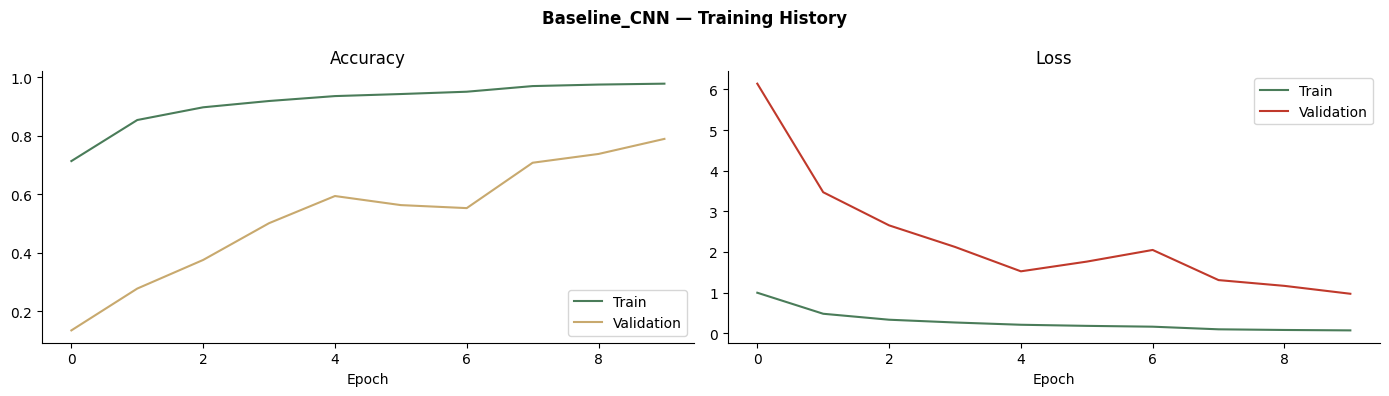


  Test Accuracy : 78.55%  |  Macro F1: 72.82%  |  Time: 9.5 min
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.37      0.96      0.53        94
                                 Apple___Black_rot       0.63      1.00      0.78        93
                          Apple___Cedar_apple_rust       0.89      0.76      0.82        41
                                   Apple___healthy       0.96      0.76      0.85       246
                               Blueberry___healthy       0.99      0.72      0.83       226
          Cherry_(including_sour)___Powdery_mildew       0.96      0.91      0.93       158
                 Cherry_(including_sour)___healthy       0.96      0.84      0.90       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.32      1.00      0.49        77
                       Corn_(maize)___Common_rust_       0.96      0.99      0.98       179
              

In [20]:
print("\n" + "="*60)
print("  MODEL 1: Baseline CNN  (128×128, from scratch)")
print("  Architecture: Sequential — 3 Conv blocks + Dense head")
print("  Max epochs: 10")
print("=" * 60)

# Build baseline datasets (simple /255 normalisation)
train_ds_base = make_dataset(balanced_train_paths, balanced_train_cat,
                             CFG["img_size_base"], CFG["batch_size"], shuffle=True)
val_ds_base   = make_dataset(val_paths,  val_cat,  CFG["img_size_base"], CFG["batch_size"], shuffle=False)
test_ds_base  = make_dataset(test_paths, test_cat, CFG["img_size_base"], CFG["batch_size"], shuffle=False)

# ── Architecture (Sequential API — from Plant_Disease_Detection_with_Baseline_CNN) ──
input_shape = (CFG["img_size_base"], CFG["img_size_base"], 3)

baseline_model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten + Dense head
    layers.Flatten(),
    layers.Dense(1000, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

baseline_model.summary()

baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=CFG["learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)

t0 = time.time()
history_baseline = baseline_model.fit(
    train_ds_base,
    epochs=CFG["epochs"],
    validation_data=val_ds_base,
    callbacks=get_callbacks("Baseline_CNN"),
)
t_baseline = time.time() - t0

plot_history(history_baseline, "Baseline_CNN")

# Evaluate  (compiled with 4 metrics: loss, accuracy, precision, recall)
eval_test  = baseline_model.evaluate(test_ds_base,  verbose=0)
eval_train = baseline_model.evaluate(train_ds_base, verbose=0)
eval_val   = baseline_model.evaluate(val_ds_base,   verbose=0)
test_loss_b,  test_acc_b  = eval_test[0],  eval_test[1]
train_loss_b, train_acc_b = eval_train[0], eval_train[1]
val_loss_b,   val_acc_b   = eval_val[0],   eval_val[1]

y_pred_b = np.argmax(baseline_model.predict(test_ds_base, verbose=0), axis=1)
y_true_b = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds_base])
report_b = classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES, output_dict=True)
macro_f1_b = report_b["macro avg"]["f1-score"] * 100

print(f"\n  Test Accuracy : {test_acc_b*100:.2f}%  |  Macro F1: {macro_f1_b:.2f}%  |  Time: {t_baseline/60:.1f} min")
print(classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES))

# Additional evaluations (matching original baseline notebook style)
print("\n── Training Set Evaluation ──")
print(f"  Train Loss: {train_loss_b:.4f}  |  Train Accuracy: {train_acc_b:.4f}")

print("\n── Validation Set Evaluation ──")
print(f"  Val Loss: {val_loss_b:.4f}  |  Val Accuracy: {val_acc_b:.4f}")

results_baseline = {
    "model_name":     "Baseline_CNN",
    "test_accuracy":  round(test_acc_b * 100, 2),
    "macro_f1":       round(macro_f1_b, 2),
    "train_time_min": round(t_baseline / 60, 1),
    "epochs_run":     len(history_baseline.history["loss"]),
}

## 📱 Model 2 — MobileNetV2

Lightest model — ~3.4M base params. **Max 10 epochs.**


  MODEL: MobileNetV2
  Strategy: top 30 base layers unfrozen
  Max epochs: 10  (EarlyStopping patience=3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Base layers — frozen: 124, trainable: 30


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,938,470 (11.21 MB)

 Trainable params: 2,204,326 (8.41 MB)

...

1909/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8611 - loss: 0.5555 - precision: 0.8994 - recall: 0.8411

2026-04-12 22:20:09.884336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:20:10.021979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8611 - loss: 0.5554 - precision: 0.8995 - recall: 0.8412

2026-04-12 22:20:34.883785: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:20:35.021899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.09342, saving model to /kaggle/working/models/MobileNetV2_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 142s 60ms/step - accuracy: 0.8611 - loss: 0.5553 - precision: 0.8995 - recall: 0.8412 - val_accuracy: 0.0934 - val_loss: 99.0543 - val_precision: 0.0935 - val_recall: 0.0934 - learning_rate: 0.0010
Epoch 2/10
1910/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9038 - loss: 0.4780 - precision: 0.9257 - recall: 0.8868
Epoch 2: val_accuracy improved from 0.09342 to 0.19826, saving model to /kaggle/working/models/MobileNetV2_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 86s 44ms/step - accuracy: 0.9038 - loss: 0.4778 - precision: 0.9257 - recall: 0.8869 - val_accuracy: 0.1983 - val_loss: 43.8420 - val_precision: 0.1985 - val_recall: 0.1981 - learning_rate: 0.0010
Epoch 3/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9307 - loss: 0.3133 - precision: 0.9446 - recall: 0.9195
Epoch 3: val_accuracy improved from 0.19826 to 0.45826, s

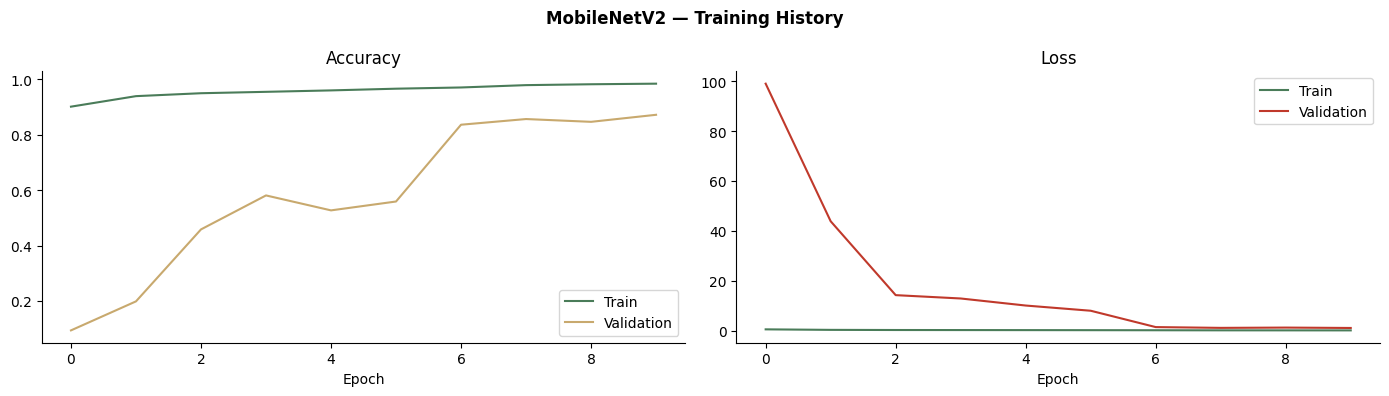


  Test Accuracy : 86.45%  |  Macro F1: 82.35%  |  Time: 15.3 min
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.75      0.98      0.85        94
                                 Apple___Black_rot       0.95      1.00      0.97        93
                          Apple___Cedar_apple_rust       1.00      0.73      0.85        41
                                   Apple___healthy       1.00      0.87      0.93       246
                               Blueberry___healthy       0.99      0.95      0.97       226
          Cherry_(including_sour)___Powdery_mildew       0.95      1.00      0.97       158
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.35      1.00      0.52        77
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       179
             

In [21]:
results_mobilenet, model_mobilenet = build_transfer_model(
    base_constructor = MobileNetV2,
    preprocess_fn    = mob_pre,
    img_size         = 224,
    name             = "MobileNetV2",
    unfreeze_layers  = 30,
    dropout          = 0.4,
)

## ✅ Model 3 — EfficientNetB0 *(Recommended)*

Best accuracy-efficiency ratio — ~5.3M base params. **Max 10 epochs.**


  MODEL: EfficientNetB0
  Strategy: top 30 base layers unfrozen
  Max epochs: 10  (EarlyStopping patience=3)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Base layers — frozen: 208, trainable: 30


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,730,057 (18.04 MB)

 Trainable params: 2,174,086 (8.29 MB)

...

1910/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8865 - loss: 0.4471 - precision: 0.9207 - recall: 0.8711

2026-04-12 22:36:12.960971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:13.103730: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:13.449938: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:13.593038: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:14.429351: E external/local_xla/xla/stream_

1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8865 - loss: 0.4470 - precision: 0.9208 - recall: 0.8712

2026-04-12 22:36:44.029096: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:44.170112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:44.500632: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:44.644035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 22:36:44.785536: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.24147, saving model to /kaggle/working/models/EfficientNetB0_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 165s 68ms/step - accuracy: 0.8865 - loss: 0.4469 - precision: 0.9208 - recall: 0.8712 - val_accuracy: 0.2415 - val_loss: 16.3385 - val_precision: 0.2432 - val_recall: 0.2410 - learning_rate: 0.0010
Epoch 2/10
1910/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9338 - loss: 0.3739 - precision: 0.9436 - recall: 0.9261
Epoch 2: val_accuracy improved from 0.24147 to 0.39480, saving model to /kaggle/working/models/EfficientNetB0_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 98s 50ms/step - accuracy: 0.9338 - loss: 0.3738 - precision: 0.9436 - recall: 0.9262 - val_accuracy: 0.3948 - val_loss: 7.5707 - val_precision: 0.3988 - val_recall: 0.3909 - learning_rate: 0.0010
Epoch 3/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9506 - loss: 0.2410 - precision: 0.9577 - recall: 0.9433
Epoch 3: val_accuracy improved from 0.39480 to 0.643

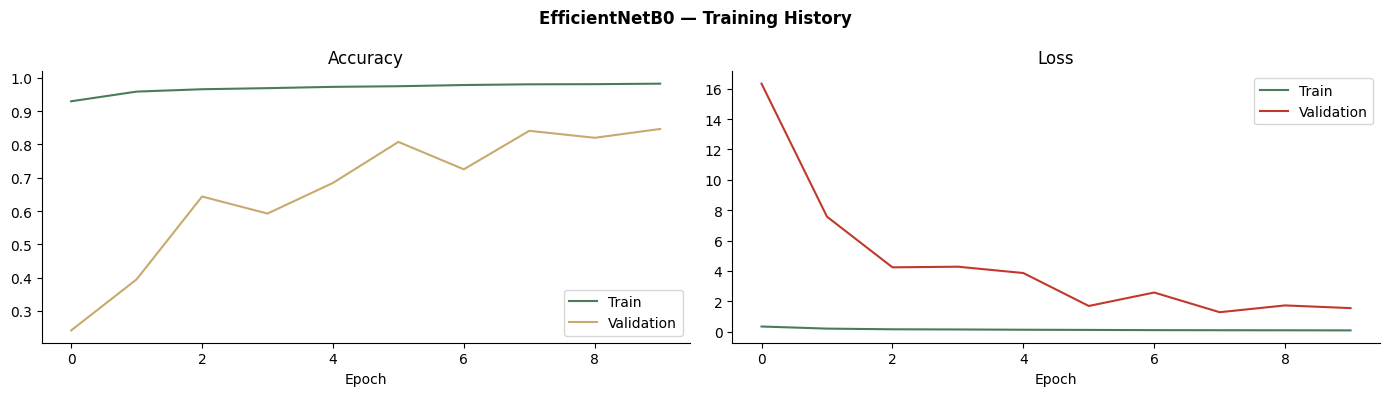


  Test Accuracy : 84.23%  |  Macro F1: 82.69%  |  Time: 17.3 min
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.63      1.00      0.77        94
                                 Apple___Black_rot       0.83      1.00      0.91        93
                          Apple___Cedar_apple_rust       1.00      0.85      0.92        41
                                   Apple___healthy       1.00      0.74      0.85       246
                               Blueberry___healthy       1.00      0.97      0.99       226
          Cherry_(including_sour)___Powdery_mildew       0.99      1.00      1.00       158
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.40      1.00      0.57        77
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       179
             

In [22]:
results_efficientnet, model_efficientnet = build_transfer_model(
    base_constructor = EfficientNetB0,
    preprocess_fn    = eff_pre,
    img_size         = 224,
    name             = "EfficientNetB0",
    unfreeze_layers  = 30,
    dropout          = 0.4,
)

## 🔗 Model 4 — ResNet50

Residual connections — ~25.6M base params. **Max 10 epochs.**


  MODEL: ResNet50
  Strategy: top 30 base layers unfrozen
  Max epochs: 10  (EarlyStopping patience=3)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Base layers — frozen: 145, trainable: 30


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,664,486 (94.09 MB)

 Trainable params: 15,522,854 (59.21 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

Epoch 1/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8915 - loss: 0.5638 - precision: 0.9157 - recall: 0.8773
Epoch 1: val_accuracy improved from -inf to 0.27240, saving model to /kaggle/working/models/ResNet50_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 317s 152ms/step - accuracy: 0.8916 - loss: 0.5637 - precision: 0.9157 - recall: 0.8774 - val_accuracy: 0.2724 - val_loss: 17.7275 - val_precision: 0.2726 - val_recall: 0.2714 - learning_rate: 0.0010
Epoch 2/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9480 - loss: 0.3620 - precision: 0.9518 - recall: 0.9448
Epoch 2: val_accuracy improved from 0.27240 to 0.56310, saving model to /kaggle/working/models/ResNet50_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 272s 141ms/step - accuracy: 0.9480 - loss: 0.3619 - precision: 0.9518 - recall: 0.9448 - val_accuracy: 0.5631 - val_loss: 6.3905 - val_precision: 0.5644 - val_recall: 0.5619 - learning_rate: 0.0010
Epoch 3/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - ac

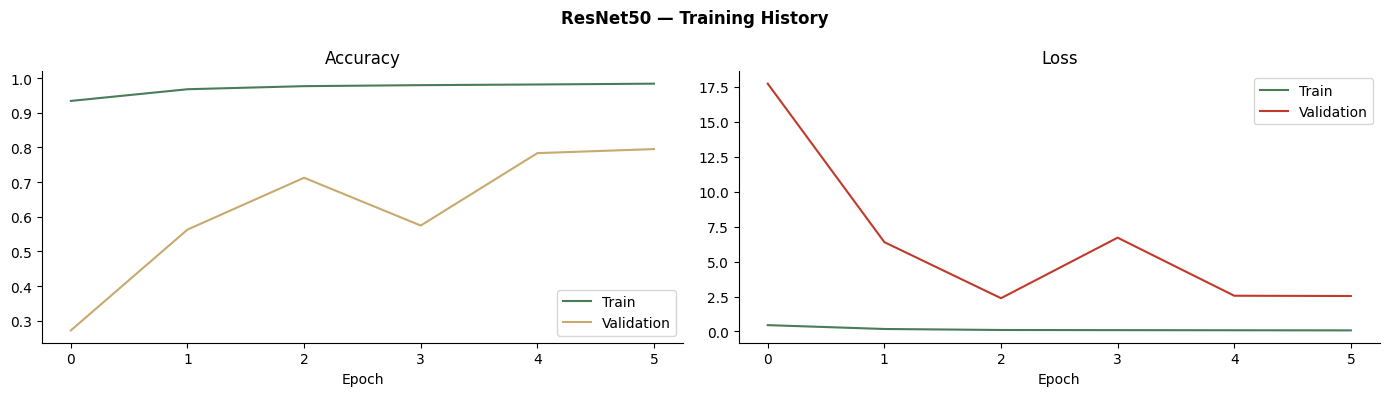


  Test Accuracy : 71.15%  |  Macro F1: 69.82%  |  Time: 27.9 min
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.38      1.00      0.55        94
                                 Apple___Black_rot       1.00      0.98      0.99        93
                          Apple___Cedar_apple_rust       1.00      0.93      0.96        41
                                   Apple___healthy       1.00      0.45      0.62       246
                               Blueberry___healthy       1.00      0.89      0.94       226
          Cherry_(including_sour)___Powdery_mildew       0.92      0.93      0.92       158
                 Cherry_(including_sour)___healthy       1.00      0.93      0.96       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.37      0.99      0.53        77
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       179
             

In [23]:
results_resnet, model_resnet = build_transfer_model(
    base_constructor = ResNet50,
    preprocess_fn    = res_pre,
    img_size         = 224,
    name             = "ResNet50",
    unfreeze_layers  = 30,
    dropout          = 0.4,
)

## 🕸️ Model 5 — DenseNet121

Dense skip connections — ~8M base params. **Max 10 epochs.**


  MODEL: DenseNet121
  Strategy: top 30 base layers unfrozen
  Max epochs: 10  (EarlyStopping patience=3)
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Base layers — frozen: 397, trainable: 30


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,585,894 (28.94 MB)

 Trainable params: 1,187,750 (4.53 MB)

 Non-trainable params: 6,398,144 (24.41 MB)

Epoch 1/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9042 - loss: 0.3471 - precision: 0.9465 - recall: 0.8807
Epoch 1: val_accuracy improved from -inf to 0.34851, saving model to /kaggle/working/models/DenseNet121_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 265s 119ms/step - accuracy: 0.9042 - loss: 0.3470 - precision: 0.9465 - recall: 0.8807 - val_accuracy: 0.3485 - val_loss: 5.6823 - val_precision: 0.3519 - val_recall: 0.3435 - learning_rate: 0.0010
Epoch 2/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9589 - loss: 0.1726 - precision: 0.9622 - recall: 0.9561
Epoch 2: val_accuracy improved from 0.34851 to 0.54775, saving model to /kaggle/working/models/DenseNet121_best.keras
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 185s 96ms/step - accuracy: 0.9589 - loss: 0.1726 - precision: 0.9622 - recall: 0.9561 - val_accuracy: 0.5478 - val_loss: 3.3856 - val_precision: 0.5494 - val_recall: 0.5433 - learning_rate: 0.0010
Epoch 3/10
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - a

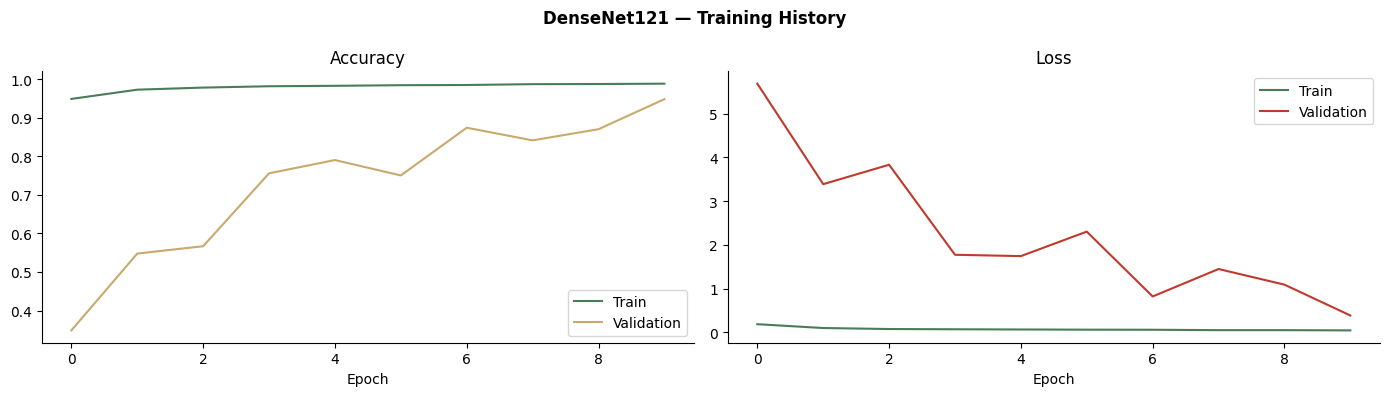


  Test Accuracy : 94.27%  |  Macro F1: 91.62%  |  Time: 32.3 min
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      1.00      0.95        94
                                 Apple___Black_rot       0.99      1.00      0.99        93
                          Apple___Cedar_apple_rust       1.00      0.98      0.99        41
                                   Apple___healthy       1.00      0.97      0.98       246
                               Blueberry___healthy       1.00      1.00      1.00       226
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       158
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.49      0.99      0.65        77
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       179
             

In [24]:
results_densenet, model_densenet = build_transfer_model(
    base_constructor = DenseNet121,
    preprocess_fn    = dns_pre,
    img_size         = 224,
    name             = "DenseNet121",
    unfreeze_layers  = 30,
    dropout          = 0.4,
)

## 🏆 Final Model Comparison


  FINAL RESULTS — Ranked by Test Accuracy  (VGG16 removed)
                test_accuracy  macro_f1  train_time_min  epochs_run
model_name                                                         
DenseNet121             94.27     91.62            32.3          10
MobileNetV2             86.45     82.35            15.3          10
EfficientNetB0          84.23     82.69            17.3          10
Baseline_CNN            78.55     72.82             9.5          10
ResNet50                71.15     69.82            27.9           6

✅ Saved → results/model_comparison.csv


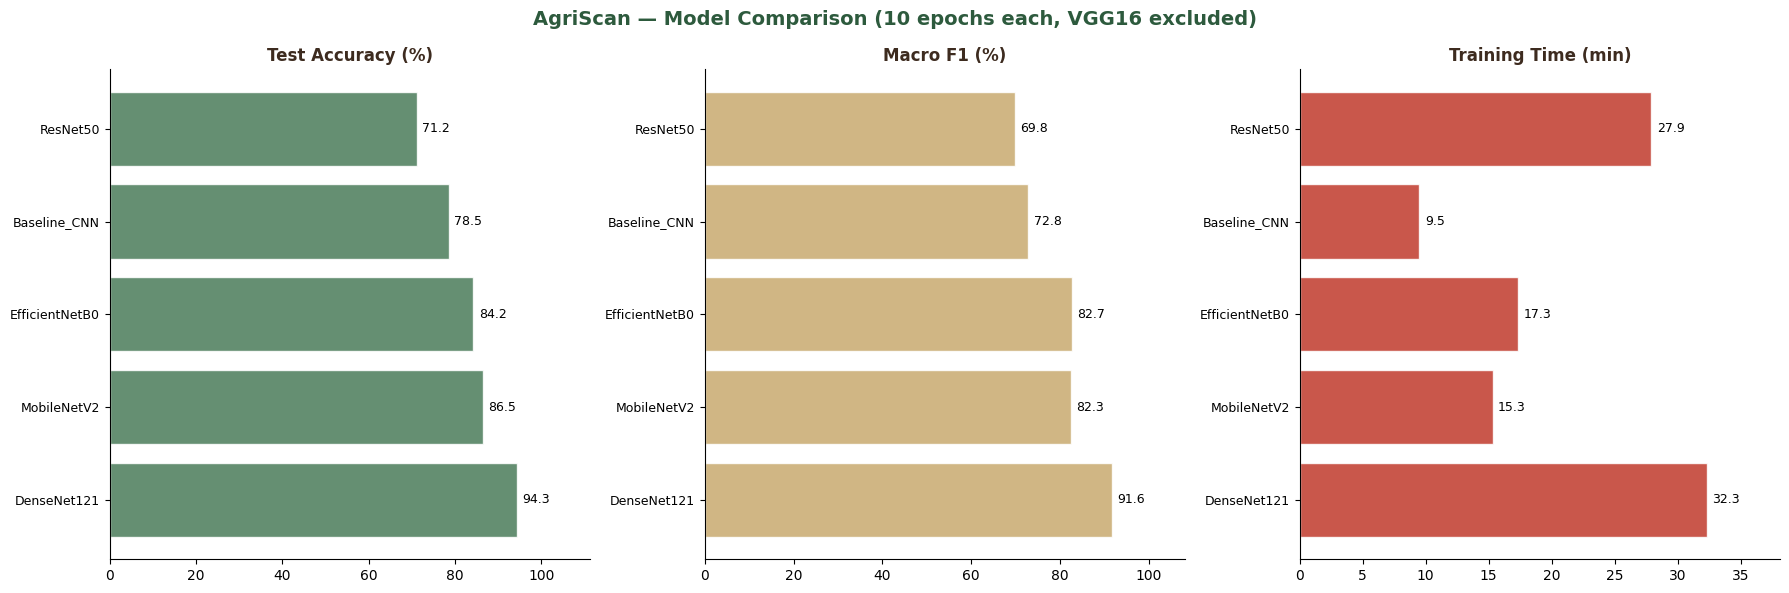

In [25]:
all_results = [
    results_baseline,
    results_mobilenet,
    results_efficientnet,
    results_resnet,
    results_densenet,
]

df = pd.DataFrame(all_results).set_index("model_name")
df = df.sort_values("test_accuracy", ascending=False)

print("\n" + "="*70)
print("  FINAL RESULTS — Ranked by Test Accuracy  (VGG16 removed)")
print("="*70)
print(df.to_string())

df.to_csv(os.path.join(CFG["results_dir"], "model_comparison.csv"))
print(f"\n✅ Saved → results/model_comparison.csv")

# Visual comparison chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("AgriScan — Model Comparison (10 epochs each, VGG16 excluded)", fontsize=14,
             fontweight="bold", color="#2d5a3d")

metrics = ["test_accuracy", "macro_f1", "train_time_min"]
titles  = ["Test Accuracy (%)", "Macro F1 (%)", "Training Time (min)"]
colors  = ["#4a7c59", "#c8a96e", "#c0392b"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals = df[metric].apply(lambda x: float(x) if x != "N/A" else 0)
    bars = ax.barh(df.index, vals, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(title, fontweight="bold", color="#3d2b1f")
    ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
    ax.set_xlim(0, vals.max() * 1.18)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CFG["results_dir"], "model_comparison_chart.png"), dpi=150)
plt.show()

## 💾 Save Best Model & Metadata

In [26]:
best_name = df.index[0]
print("="*60)
print(f"🏆 BEST MODEL  : {best_name}")
print(f"  Test Accuracy : {df.loc[best_name, 'test_accuracy']}%")
print(f"  Macro F1      : {df.loc[best_name, 'macro_f1']}%")
print(f"  Epochs run    : {df.loc[best_name, 'epochs_run']}")
print(f"  Training time : {df.loc[best_name, 'train_time_min']} min")
print("="*60)

model_map = {
    "Baseline_CNN":   baseline_model,
    "MobileNetV2":    model_mobilenet,
    "EfficientNetB0": model_efficientnet,
    "ResNet50":       model_resnet,
    "DenseNet121":    model_densenet,
}

# ── Save ALL models individually ──────────────────────────────────────────────
print("\nSaving all models...")
print("-" * 50)
for model_name, model_obj in model_map.items():
    save_path = os.path.join(CFG["output_dir"], f"{model_name}_final.keras")
    model_obj.save(save_path)
    marker = " 🏆 ← BEST" if model_name == best_name else ""
    print(f"  ✅ {model_name}_final.keras{marker}")

# ── Save best model copy ──────────────────────────────────────────────────────
best_model = model_map[best_name]
best_model.save(os.path.join(CFG["output_dir"], "best_model.keras"))
print(f"\n  ✅ best_model.keras (copy of {best_name})")
print("-" * 50)

# ── Save metadata ─────────────────────────────────────────────────────────────
metadata = {
    "class_names":   CLASS_NAMES,
    "num_classes":   NUM_CLASSES,
    "best_model":    best_name,
    "img_size":      CFG["img_size"],
    "img_size_base": CFG["img_size_base"],
    "trained_at":    datetime.now().isoformat(),
    "results":       df.reset_index().to_dict(orient="records"),
}
with open(os.path.join(CFG["output_dir"], "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print("\n✅ metadata.json saved")

🏆 BEST MODEL  : DenseNet121
  Test Accuracy : 94.27%
  Macro F1      : 91.62%
  Epochs run    : 10
  Training time : 32.3 min

Saving all models...
--------------------------------------------------
  ✅ Baseline_CNN_final.keras
  ✅ MobileNetV2_final.keras
  ✅ EfficientNetB0_final.keras
  ✅ ResNet50_final.keras
  ✅ DenseNet121_final.keras 🏆 ← BEST

  ✅ best_model.keras (copy of DenseNet121)
--------------------------------------------------

✅ metadata.json saved


In [27]:
import shutil

# Zip models/ and results/ into one archive
shutil.make_archive("/kaggle/working/AgriScan_outputs", "zip", "/kaggle/working")

print("✅ AgriScan_outputs.zip created")
print("   → Go to Output panel on the right → download AgriScan_outputs.zip")

✅ AgriScan_outputs.zip created
   → Go to Output panel on the right → download AgriScan_outputs.zip
